In [1]:
import os

path = r"C:\Users\bindu\OneDrive\Desktop\bluestock_mf_capstone\data\raw"
os.listdir(path)

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'HDFC_Top100_live_nav.csv']

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\bindu\OneDrive\Desktop\bluestock_mf_capstone\data\raw\02_nav_history.csv")

df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
df.columns
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [4]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])

In [5]:
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

In [6]:
df[['amfi_code', 'date', 'nav', 'daily_return']].head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
df = df.dropna(subset=['daily_return'])

In [8]:
df.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [9]:
df['amfi_code'].nunique()

40

In [10]:
df = df.sort_values(['amfi_code', 'date'])

In [11]:
import numpy as np

def cagr(nav_series):
    start = nav_series.iloc[0]
    end = nav_series.iloc[-1]
    n_years = len(nav_series) / 252  # trading days
    return (end / start) ** (1 / n_years) - 1

In [12]:
cagr_df = df.groupby('amfi_code')['nav'].apply(cagr).reset_index()
cagr_df.columns = ['amfi_code', 'cagr']
cagr_df.head()

,amfi_code,cagr
0,100016,0.027767
1,100025,0.043801
2,100033,0.293078
3,101206,0.225955
4,101207,0.079084


In [13]:
df['date'].min(), df['date'].max()

(Timestamp('2022-01-04 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [14]:
latest_date = df['date'].max()
one_year_ago = latest_date - pd.Timedelta(days=365)

df_1y = df[df['date'] >= one_year_ago]
print(df_1y.shape)

(10480, 4)


In [15]:
df_1y.head()

,amfi_code,date,nav,daily_return
6638,100016,2025-05-29,596.8877,-0.002982
6639,100016,2025-05-30,596.9773,0.000150
6640,100016,2025-06-02,591.5240,-0.009135
6641,100016,2025-06-03,601.2816,0.016496
6642,100016,2025-06-04,597.0806,-0.006987


In [16]:
import numpy as np

def cagr(series):
    start = series.iloc[0]
    end = series.iloc[-1]
    n_years = len(series) / 252
    if n_years == 0:
        return np.nan
    return (end / start) ** (1 / n_years) - 1

In [17]:
cagr_1y = df_1y.groupby('amfi_code')['nav'].apply(cagr).reset_index()
cagr_1y.columns = ['amfi_code', 'cagr_1y']

cagr_1y.head()

,amfi_code,cagr_1y
0,100016,-0.021403
1,100025,0.035611
2,100033,0.507565
3,101206,0.457300
4,101207,-0.231862


In [18]:
rf = 0.065 / 252

In [19]:
df = df.dropna(subset=['daily_return'])

In [20]:
import numpy as np

def sharpe_ratio(returns):
    rf = 0.065 / 252
    excess = returns - rf
    return (excess.mean() / excess.std()) * np.sqrt(252)

In [21]:
sharpe_df = df.groupby('amfi_code')['daily_return'].apply(sharpe_ratio).reset_index()
sharpe_df.columns = ['amfi_code', 'sharpe_ratio']

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [22]:
import numpy as np

def sortino_ratio(returns):
    rf = 0.065 / 252
    
    downside = returns[returns < 0].std()
    
    if downside == 0 or np.isnan(downside):
        return np.nan
    
    return ((returns.mean() - rf) / downside) * np.sqrt(252)

In [23]:
sortino_df = df.groupby('amfi_code')['daily_return'].apply(sortino_ratio).reset_index()
sortino_df.columns = ['amfi_code', 'sortino_ratio']

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [24]:
benchmark = pd.read_csv(r"C:\Users\bindu\OneDrive\Desktop\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [25]:
df['date'] = pd.to_datetime(df['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [26]:
print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [27]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [28]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [29]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty = nifty.sort_values('date')

In [30]:
nifty['market_return'] = nifty['close_value'].pct_change()
nifty.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [31]:
nifty = nifty[['date', 'market_return']]

In [32]:
df['date'] = pd.to_datetime(df['date'])

merged = pd.merge(df, nifty, on='date', how='inner')
merged.head()

,amfi_code,date,nav,daily_return,market_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [33]:
from scipy.stats import linregress

def alpha_beta(data):
    slope, intercept, r, p, se = linregress(
        data['market_return'], 
        data['daily_return']
    )
    
    beta = slope
    alpha = intercept * 252
    
    return pd.Series({'alpha': alpha, 'beta': beta})

In [34]:
alpha_beta_df = merged.groupby('amfi_code').apply(alpha_beta).reset_index()

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
merged = df.merge(
    nifty[['date', 'market_return']],
    on='date',
    how='inner'
)

In [36]:
merged = merged.dropna(subset=['daily_return', 'market_return'])

In [37]:
merged.groupby('amfi_code').size().head()

amfi_code
100016    1149
100025    1149
100033    1149
101206    1149
101207    1149
dtype: int64

In [38]:
from scipy.stats import linregress

def alpha_beta(data):
    if len(data) < 30:
        return pd.Series({'alpha': None, 'beta': None})
    
    slope, intercept, r, p, se = linregress(
        data['market_return'],
        data['daily_return']
    )
    
    return pd.Series({
        'alpha': intercept * 252,
        'beta': slope
    })

In [39]:
merged = merged.sort_values(['amfi_code', 'date'])

In [40]:
merged = merged.dropna(subset=['daily_return', 'market_return'])

In [41]:
def alpha_beta(data):
    data = data.sort_values('date')
    
    if len(data) < 30:
        return pd.Series({'alpha': None, 'beta': None})
    
    slope, intercept, r, p, se = linregress(
        data['market_return'],
        data['daily_return']
    )
    
    return pd.Series({
        'alpha': intercept * 252,
        'beta': slope
    })

In [42]:
alpha_beta_df = merged.groupby('amfi_code').apply(alpha_beta).reset_index()
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [43]:
score = cagr_df.merge(sharpe_df, on='amfi_code') \
                .merge(sortino_df, on='amfi_code') \
                .merge(alpha_beta_df, on='amfi_code')

In [44]:
score['cagr_rank'] = score['cagr'].rank(ascending=False)
score['sharpe_rank'] = score['sharpe_ratio'].rank(ascending=False)
score['sortino_rank'] = score['sortino_ratio'].rank(ascending=False)
score['alpha_rank'] = score['alpha'].rank(ascending=False)

In [45]:
score['final_score'] = (
    0.30 * score['cagr_rank'] +
    0.30 * score['sharpe_rank'] +
    0.20 * score['sortino_rank'] +
    0.20 * score['alpha_rank']
)

In [46]:
score['final_score'] = 100 - (score['final_score'] / score['final_score'].max()) * 100

In [47]:
score.sort_values('final_score', ascending=False).head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,final_score
25,120505,0.320935,1.180101,2.029353,0.292636,0.000549,1.0,5.0,5.0,3.0,91.029024
36,148569,0.304347,1.234930,2.146914,0.282704,0.018134,4.0,3.0,3.0,4.0,90.765172
34,148567,0.291981,1.448291,2.385644,0.269838,0.023684,6.0,1.0,1.0,7.0,90.237467
30,120843,0.291668,1.306744,2.364320,0.273305,-0.022830,7.0,2.0,2.0,5.0,89.182058
2,100033,0.293078,1.093699,1.829134,0.271954,0.005104,5.0,7.0,8.0,6.0,83.113456
19,119551,0.248158,1.208267,2.140267,0.232010,-0.031751,10.0,4.0,4.0,10.0,81.530343
38,149323,0.283960,1.132122,1.875101,0.265986,-0.002523,8.0,6.0,6.0,8.0,81.530343
21,119598,0.315542,0.945308,1.675317,0.303370,-0.023196,2.0,14.0,12.0,1.0,80.474934
39,149324,0.313001,0.949796,1.619793,0.300579,0.011455,3.0,13.0,14.0,2.0,78.891821
9,118632,0.231354,1.081659,1.850133,0.218294,-0.008354,11.0,8.0,7.0,11.0,75.461741


In [48]:
def max_drawdown(nav):
    cummax = nav.cummax()
    drawdown = nav / cummax - 1
    return drawdown.min()

In [49]:
score.to_csv("fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

In [50]:
import os

os.listdir()

['Advanced_Analytics.ipynb',
 'alpha_beta.csv',
 'benchmark_comparison.png',
 'EDA_Analysis.ipynb',
 'final_fund_scorecard.csv',
 'fund_scorecard.csv',
 'Performance_Analytics.ipynb',
 'rolling_sharpe_chart.png',
 'var_cvar_report.csv']

In [51]:
import numpy as np

def max_drawdown(nav_series):
    nav_series = nav_series.dropna()
    
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    
    return drawdown.min()

In [52]:
drawdown_df = df.groupby('amfi_code')['nav'].apply(max_drawdown).reset_index()
drawdown_df.columns = ['amfi_code', 'max_drawdown']

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [53]:
score = score.merge(drawdown_df, on='amfi_code', how='left')
score.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,final_score,max_drawdown
0,100016,0.027767,-0.201517,-0.351047,0.037476,-0.058268,37.0,35.0,36.0,39.0,3.430079,-0.247344
1,100025,0.043801,-0.567095,-0.941821,0.042818,0.001158,36.0,39.0,39.0,38.0,0.000000,-0.043083
2,100033,0.293078,1.093699,1.829134,0.271954,0.005104,5.0,7.0,8.0,6.0,83.113456,-0.162172
3,101206,0.225955,1.027213,1.799563,0.213998,0.021086,13.0,9.0,10.0,12.0,70.976253,-0.112916
4,101207,0.079084,0.162661,0.276644,0.108971,-0.065289,27.0,28.0,28.0,27.0,27.440633,-0.354469


In [54]:
score['drawdown_rank'] = score['max_drawdown'].rank(ascending=False)

In [55]:
score['final_score_v2'] = (
    0.25 * score['cagr_rank'] +
    0.25 * score['sharpe_rank'] +
    0.15 * score['sortino_rank'] +
    0.15 * score['alpha_rank'] +
    0.20 * score['drawdown_rank']
)

In [56]:
score['final_score_v2'] = 100 - (score['final_score_v2'] / score['final_score_v2'].max()) * 100

In [57]:
score.sort_values('final_score_v2', ascending=False).head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,final_score,max_drawdown,drawdown_rank,final_score_v2
34,148567,0.291981,1.448291,2.385644,0.269838,0.023684,6.0,1.0,1.0,7.0,90.237467,-0.112657,8.0,87.785235
30,120843,0.291668,1.306744,2.364320,0.273305,-0.022830,7.0,2.0,2.0,5.0,89.182058,-0.129740,13.0,84.161074
36,148569,0.304347,1.234930,2.146914,0.282704,0.018134,4.0,3.0,3.0,4.0,90.765172,-0.163967,21.0,81.208054
25,120505,0.320935,1.180101,2.029353,0.292636,0.000549,1.0,5.0,5.0,3.0,91.029024,-0.181885,25.0,79.328859
19,119551,0.248158,1.208267,2.140267,0.232010,-0.031751,10.0,4.0,4.0,10.0,81.530343,-0.150124,17.0,75.838926
2,100033,0.293078,1.093699,1.829134,0.271954,0.005104,5.0,7.0,8.0,6.0,83.113456,-0.162172,20.0,75.570470
38,149323,0.283960,1.132122,1.875101,0.265986,-0.002523,8.0,6.0,6.0,8.0,81.530343,-0.172481,22.0,73.154362
3,101206,0.225955,1.027213,1.799563,0.213998,0.021086,13.0,9.0,10.0,12.0,70.976253,-0.112916,9.0,71.543624
24,120504,0.227035,1.026524,1.805294,0.211948,0.016232,12.0,10.0,9.0,13.0,70.976253,-0.125883,12.0,69.932886
9,118632,0.231354,1.081659,1.850133,0.218294,-0.008354,11.0,8.0,7.0,11.0,75.461741,-0.174141,23.0,67.651007


In [58]:
top5 = score.sort_values('final_score_v2', ascending=False).head(5)
top5_ids = top5['amfi_code'].tolist()

In [59]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])

In [60]:
import matplotlib.pyplot as plt

fund_cum = {}

for fund in top5_ids:
    temp = df[df['amfi_code'] == fund].copy()
    temp = temp.sort_values('date')
    
    temp['cum_return'] = (1 + temp['daily_return']).cumprod()
    
    fund_cum[fund] = temp[['date', 'cum_return']]

In [61]:
nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()

nifty50 = nifty50.sort_values('date')
nifty100 = nifty100.sort_values('date')

nifty50['ret'] = nifty50['close_value'].pct_change()
nifty100['ret'] = nifty100['close_value'].pct_change()

nifty50['cum'] = (1 + nifty50['ret']).cumprod()
nifty100['cum'] = (1 + nifty100['ret']).cumprod()

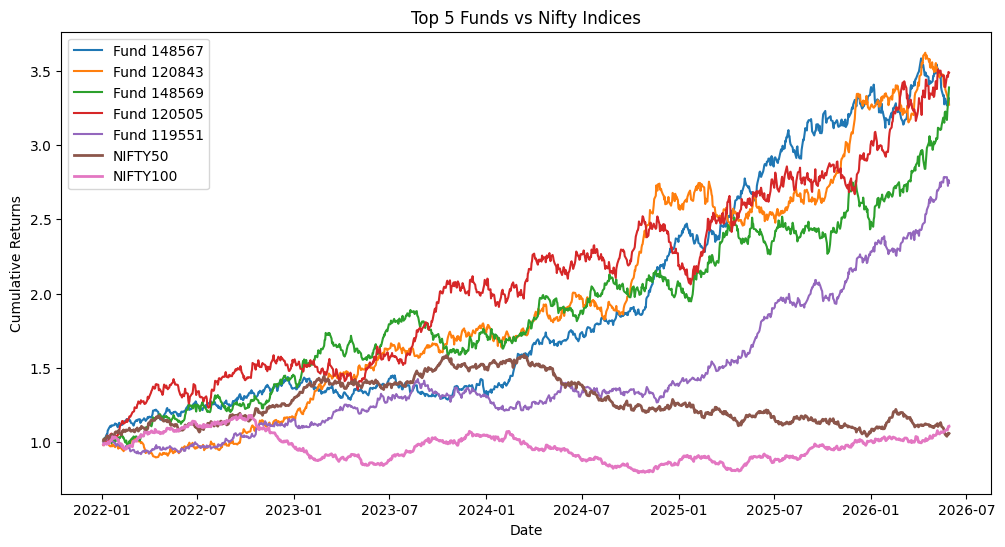

In [62]:
plt.figure(figsize=(12,6))

for fund in fund_cum:
    plt.plot(fund_cum[fund]['date'], fund_cum[fund]['cum_return'], label=f'Fund {fund}')

plt.plot(nifty50['date'], nifty50['cum'], label='NIFTY50', linewidth=2)
plt.plot(nifty100['date'], nifty100['cum'], label='NIFTY100', linewidth=2)

plt.legend()
plt.title("Top 5 Funds vs Nifty Indices")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.show()

In [63]:
import numpy as np

def tracking_error(fund_ret, bench_ret):
    return np.std(fund_ret - bench_ret) * np.sqrt(252)

In [64]:
merged = pd.merge(df[df['amfi_code']==top5_ids[0]],
                  nifty100[['date','ret']],
                  on='date')

tracking_error(merged['daily_return'], merged['ret'])

np.float64(0.18958112571835656)

In [65]:
plt.savefig("benchmark_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [66]:
final_output = score.sort_values('final_score_v2', ascending=False)

final_output.to_csv("final_fund_scorecard.csv", index=False)